In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
df = pd.read_csv("IPL Dataset 2008-2022.csv")
df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225954 entries, 0 to 225953
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 225954 non-null  int64 
 1   innings            225954 non-null  int64 
 2   overs              225954 non-null  int64 
 3   ballnumber         225954 non-null  int64 
 4   batter             225954 non-null  object
 5   bowler             225954 non-null  object
 6   non-striker        225954 non-null  object
 7   extra_type         12049 non-null   object
 8   batsman_run        225954 non-null  int64 
 9   extras_run         225954 non-null  int64 
 10  total_run          225954 non-null  int64 
 11  non_boundary       225954 non-null  int64 
 12  isWicketDelivery   225954 non-null  int64 
 13  player_out         11151 non-null   object
 14  kind               11151 non-null   object
 15  fielders_involved  7988 non-null    object
 16  BattingTeam        2

In [4]:
df.describe()

,ID,innings,overs,ballnumber,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery
count,2.259540e+05,225954.000000,225954.000000,225954.000000,225954.000000,225954.000000,225954.00000,225954.000000,225954.000000
mean,8.320470e+05,1.483868,9.185679,3.619750,1.243523,0.066907,1.31043,0.000093,0.049351
std,3.379542e+05,0.503104,5.681797,1.810633,1.618166,0.341470,1.60605,0.009640,0.216600
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,5.012620e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,8.297370e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.00000,0.000000,0.000000
75%,1.178395e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.00000,0.000000,0.000000
max,1.312200e+06,6.000000,19.000000,10.000000,6.000000,7.000000,7.00000,1.000000,1.000000


In [5]:
df.isnull().sum()

ID                        0
innings                   0
overs                     0
ballnumber                0
batter                    0
bowler                    0
non-striker               0
extra_type           213905
batsman_run               0
extras_run                0
total_run                 0
non_boundary              0
isWicketDelivery          0
player_out           214803
kind                 214803
fielders_involved    217966
BattingTeam               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['ID', 'innings', 'overs', 'ballnumber', 'batter', 'bowler',
       'non-striker', 'extra_type', 'batsman_run', 'extras_run', 'total_run',
       'non_boundary', 'isWicketDelivery', 'player_out', 'kind',
       'fielders_involved', 'BattingTeam'],
      dtype='object')

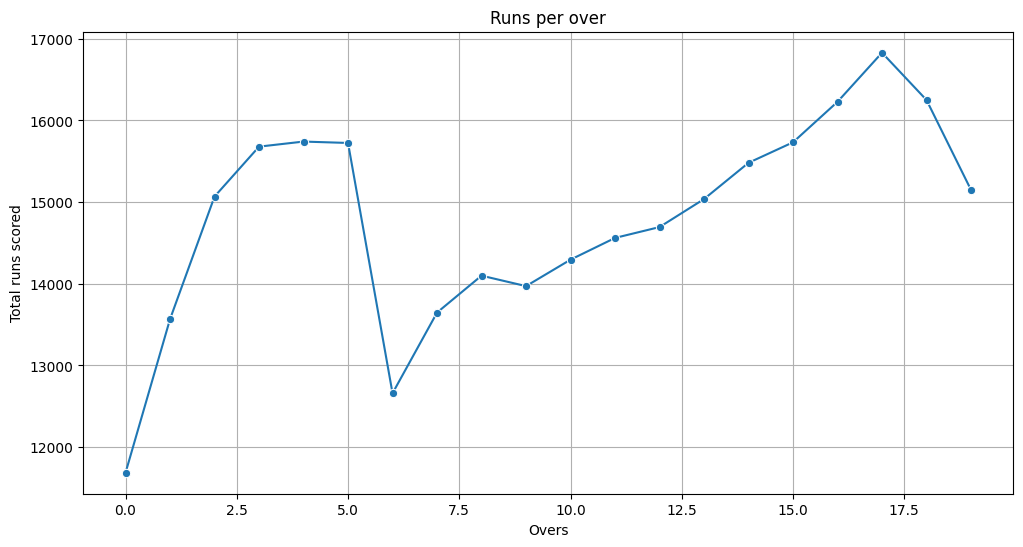

In [8]:
plt.figure(figsize=(12,6))
run_rate = df.groupby('overs')['total_run'].sum()

sns.lineplot(x= run_rate.index, y = run_rate.values, marker='o')
plt.title("Runs per over")
plt.xlabel("Overs")
plt.ylabel("Total runs scored")
plt.grid()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_68912\2196873794.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_scorers.values, y = top_scorers.index, palette="viridis")


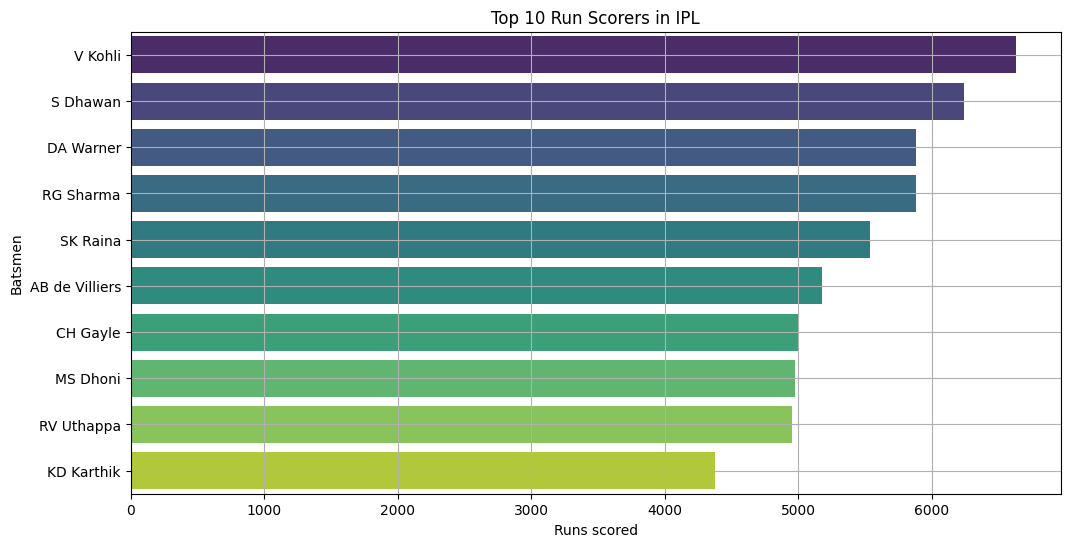

In [9]:
plt.figure(figsize=(12,6))
top_scorers = df.groupby(['batter'])["batsman_run"].sum().nlargest(10)

sns.barplot(x = top_scorers.values, y = top_scorers.index, palette="viridis")
plt.title("Top 10 Run Scorers in IPL") 
plt.xlabel("Runs scored")
plt.ylabel("Batsmen")
plt.grid()
plt.show()


C:\Users\joshi\AppData\Local\Temp\ipykernel_68912\69625218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_wicket_takers.values, y = top_wicket_takers.index, palette="rocket")


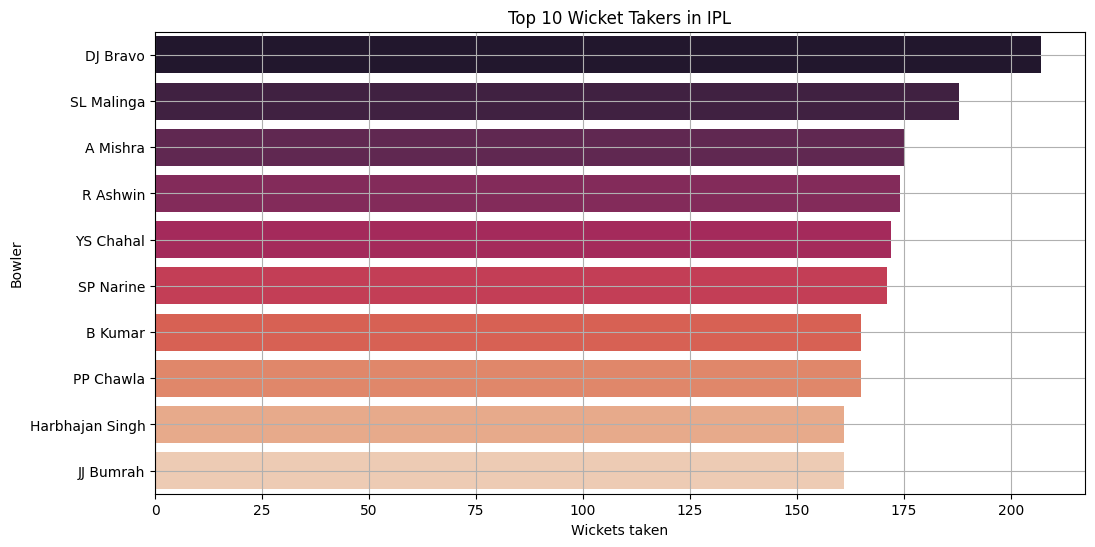

In [10]:
plt.figure(figsize=(12,6))

top_wicket_takers = df[df["isWicketDelivery"] == 1].groupby(['bowler']).size().nlargest(10).sort_values(ascending=False)

sns.barplot(x = top_wicket_takers.values, y = top_wicket_takers.index, palette="rocket")
plt.title("Top 10 Wicket Takers in IPL") 
plt.xlabel("Wickets taken")
plt.ylabel("Bowler")
plt.grid()
plt.show()

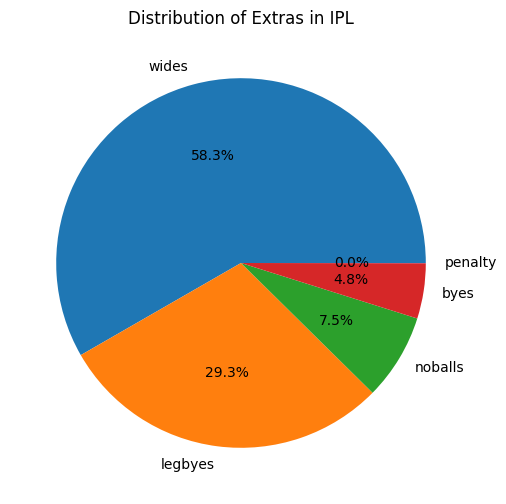

In [11]:
plt.figure(figsize=(12,6))

extra_types = df['extra_type'].value_counts()

plt.pie(x = extra_types.values, labels = extra_types.index, autopct='%1.1f%%')
plt.title("Distribution of Extras in IPL")
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_68912\2384615061.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = dismissal_types.index, y = dismissal_types.values, palette="muted")


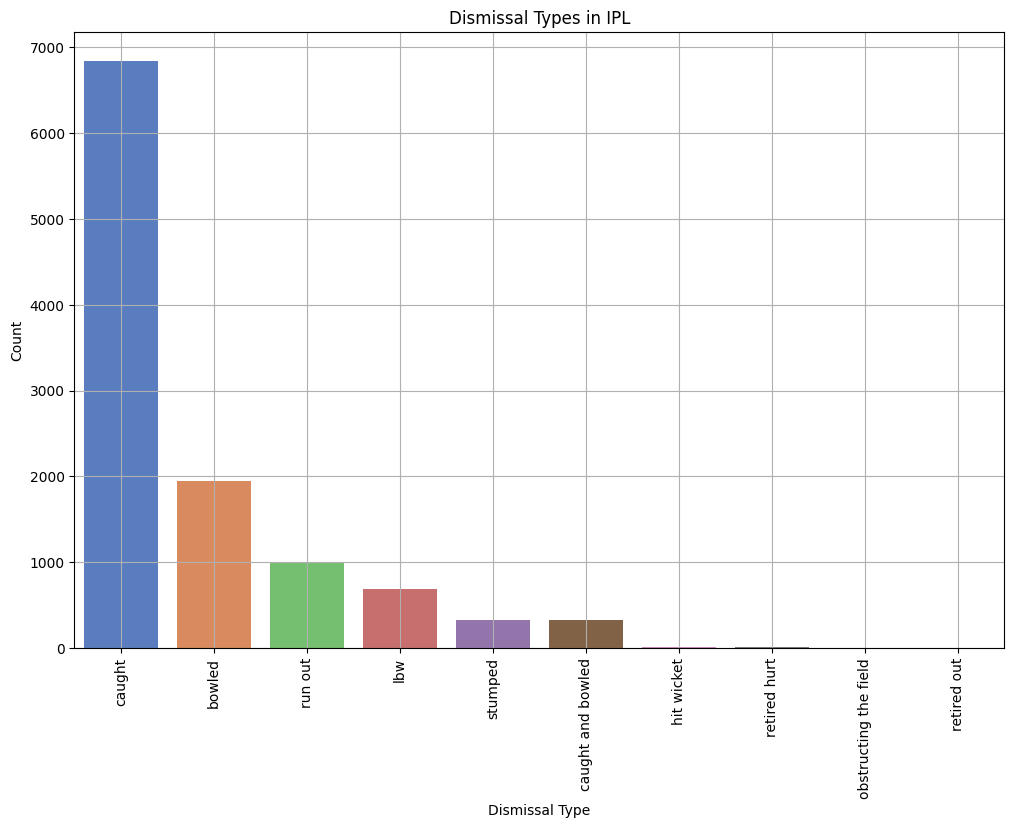

In [12]:
plt.figure(figsize=(12,8))

dismissal_types = df['kind'].value_counts()

sns.barplot(x = dismissal_types.index, y = dismissal_types.values, palette="muted")
plt.title("Dismissal Types in IPL")
plt.xlabel("Dismissal Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.grid()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_68912\2595173023.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = runs_per_inning['BattingTeam'], y = runs_per_inning['total_run'], palette="coolwarm")


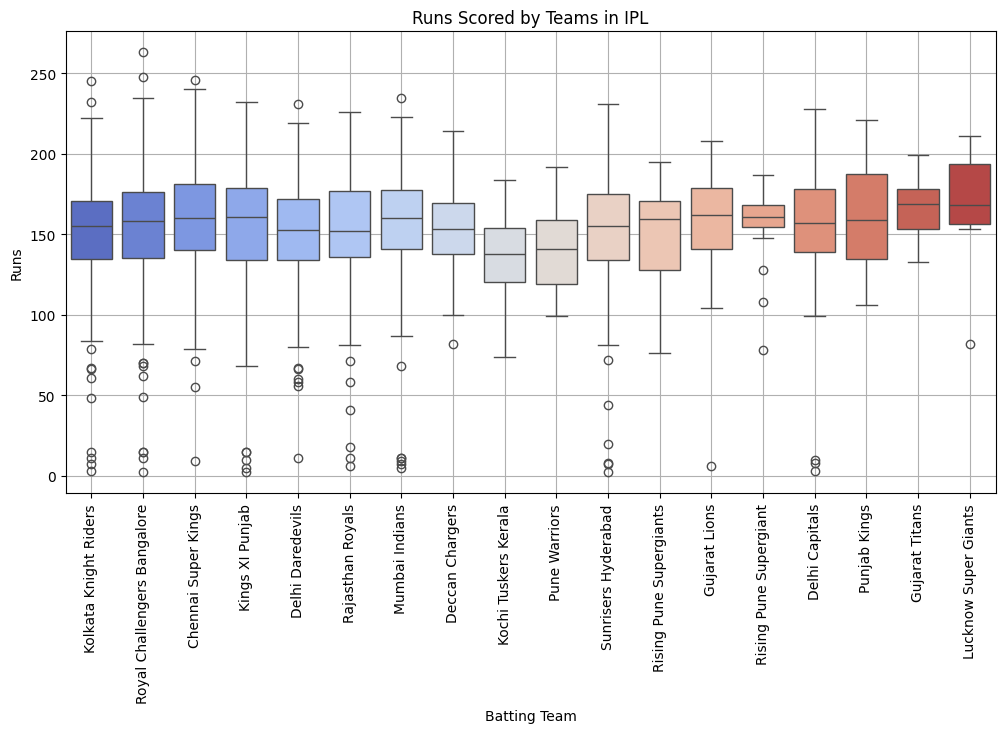

In [13]:
plt.figure(figsize=(12,6))
runs_per_inning = df.groupby(['ID','BattingTeam', 'innings'])['total_run'].sum().to_frame().reset_index()

sns.boxplot(x = runs_per_inning['BattingTeam'], y = runs_per_inning['total_run'], palette="coolwarm")
plt.title("Runs Scored by Teams in IPL")
plt.xlabel("Batting Team")
plt.ylabel("Runs")
plt.xticks(rotation=90)
plt.grid()
plt.show()

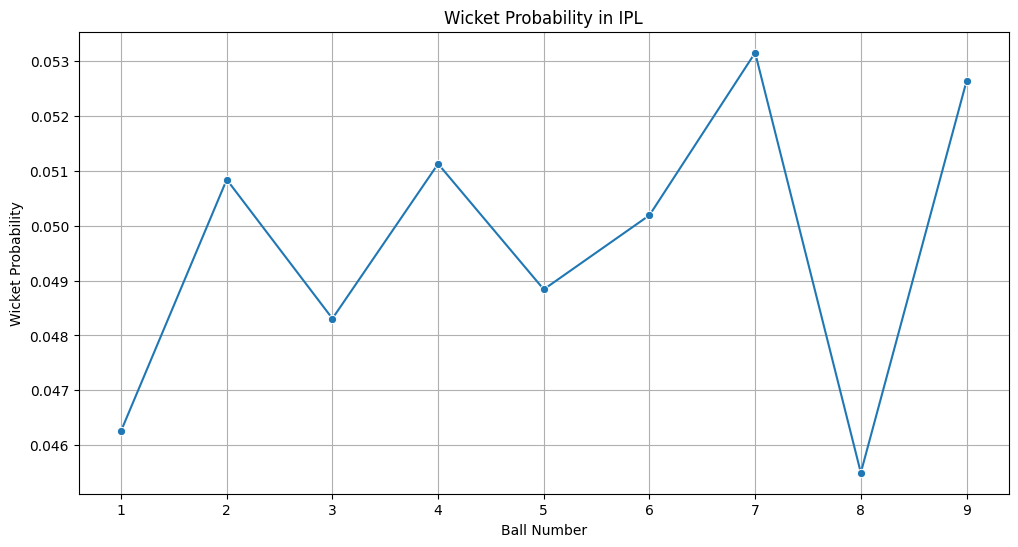

In [14]:
plt.figure(figsize=(12,6))

wicket_probability = df[df['isWicketDelivery'] == 1].groupby('ballnumber').size()/df.groupby('ballnumber').size()

sns.lineplot(x = wicket_probability.index, y = wicket_probability.values, marker='o')
plt.title("Wicket Probability in IPL")
plt.xlabel("Ball Number")
plt.ylabel("Wicket Probability")
plt.grid()
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [16]:
label_encoders={}
categorical_columns = ['batter', 'bowler', 'non-striker', 'extra_type', 'player_out', 'kind', 'fielders_involved', 'BattingTeam']

for col in categorical_columns:
    le= LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col]=le

In [17]:
df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,596,275,217,2,0,0,0,0,0,573,5,535,13
1,1312200,1,0,2,596,275,217,1,0,1,1,0,0,573,5,535,13
2,1312200,1,0,3,219,275,587,2,1,0,1,0,0,573,5,535,13
3,1312200,1,0,4,596,275,217,2,0,0,0,0,0,573,5,535,13
4,1312200,1,0,5,596,275,217,2,0,0,0,0,0,573,5,535,13


In [18]:
X = df.drop(columns=['isWicketDelivery']) #features
y = df['isWicketDelivery'] # target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
def train_and_evaluate(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)*100
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nAccuracy for {model_name}: {accuracy:.2f}")
    print(f"\nConfusion Matrix for {model_name}:")
    print(cm)
    print(f"\nClassification Report for {model_name}: ")
    print(classification_report(y_test, y_pred))
    # plot confusion matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot = True, fmt='d', cmap='Blues')
    plt.xlabel("Predicated")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

In [20]:
models = {
    "Random Forest":RandomForestClassifier(),
    "Decision Tree":DecisionTreeClassifier(),
    "KNN":KNeighborsClassifier(),
    "Naive Bayes":GaussianNB()
}


Accuracy for Random Forest: 100.00

Confusion Matrix for Random Forest:
[[42945     0]
 [    0  2246]]

Classification Report for Random Forest: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      1.00      1.00      2246

    accuracy                           1.00     45191
   macro avg       1.00      1.00      1.00     45191
weighted avg       1.00      1.00      1.00     45191



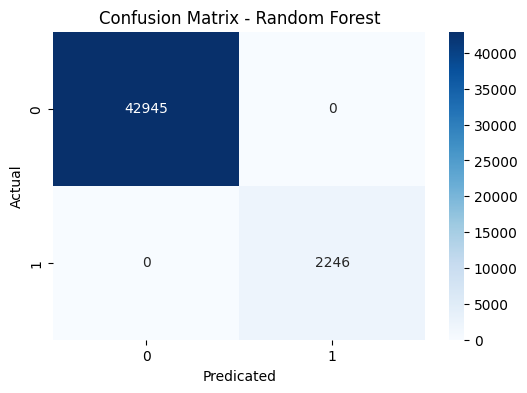


Accuracy for Decision Tree: 100.00

Confusion Matrix for Decision Tree:
[[42945     0]
 [    0  2246]]

Classification Report for Decision Tree: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      1.00      1.00      2246

    accuracy                           1.00     45191
   macro avg       1.00      1.00      1.00     45191
weighted avg       1.00      1.00      1.00     45191



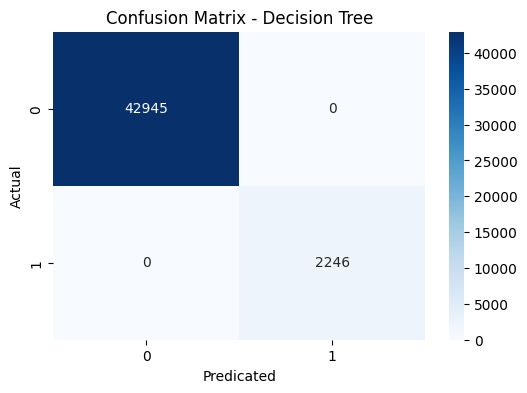


Accuracy for KNN: 99.64

Confusion Matrix for KNN:
[[42945     0]
 [  163  2083]]

Classification Report for KNN: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      0.93      0.96      2246

    accuracy                           1.00     45191
   macro avg       1.00      0.96      0.98     45191
weighted avg       1.00      1.00      1.00     45191



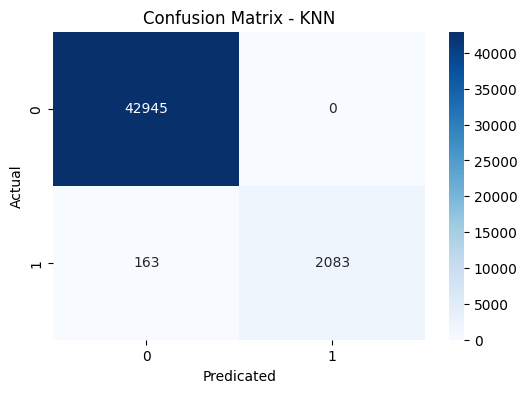


Accuracy for Naive Bayes: 99.87

Confusion Matrix for Naive Bayes:
[[42945     0]
 [   57  2189]]

Classification Report for Naive Bayes: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42945
           1       1.00      0.97      0.99      2246

    accuracy                           1.00     45191
   macro avg       1.00      0.99      0.99     45191
weighted avg       1.00      1.00      1.00     45191



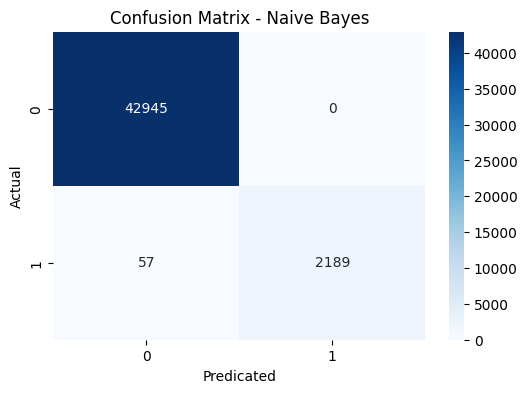

: 

In [ ]:
for model_name,model in models.items():
    train_and_evaluate(model,model_name)